In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape)
print(y_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
(60000,)


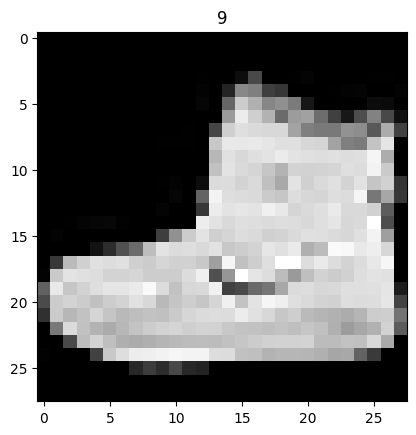

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

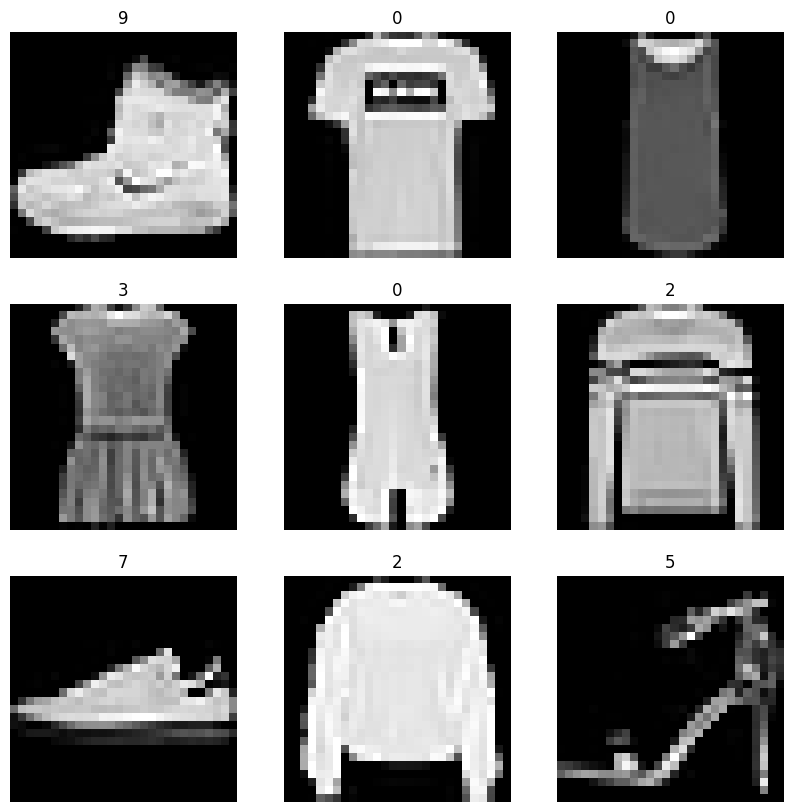

In [ ]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

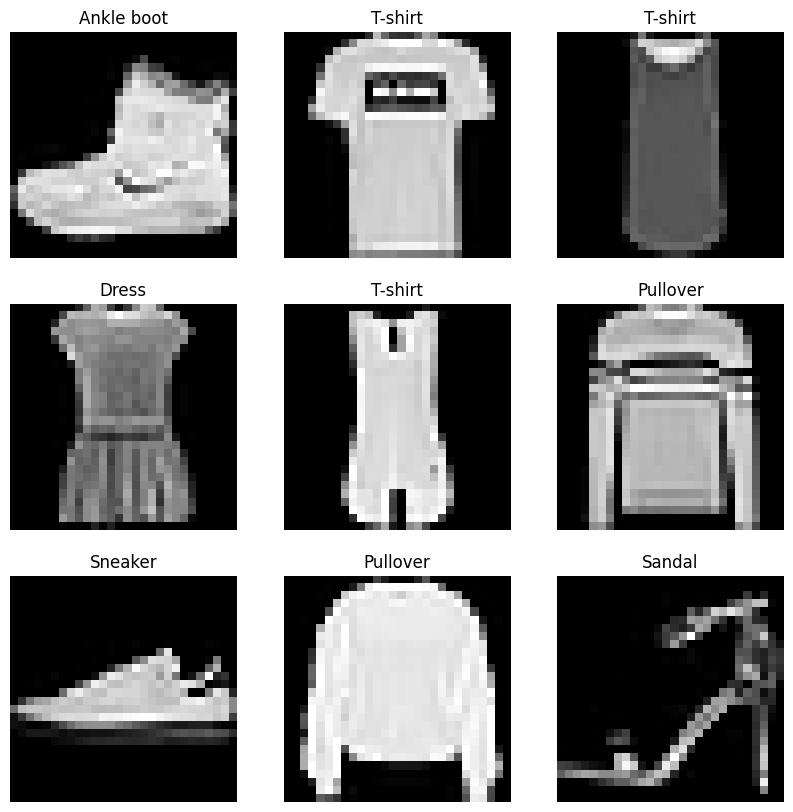

In [ ]:
class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)


In [ ]:
import numpy as np
print("Classes:", np.unique(y_train))

Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Add channel dimension (grayscale → 1 channel)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Check shape
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# 🔹 1. Convolution Layer
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(28,28,1)
))

# 🔹 2. Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# 🔹 3. Flatten
model.add(Flatten())

# 🔹 4. Dense Layer
model.add(Dense(128, activation='relu'))

# 🔹 5. Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.8543 - loss: 0.4136 - val_accuracy: 0.8732 - val_loss: 0.3574
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.8991 - loss: 0.2801 - val_accuracy: 0.9060 - val_loss: 0.2665
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9137 - loss: 0.2326 - val_accuracy: 0.9070 - val_loss: 0.2524
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9278 - loss: 0.1961 - val_accuracy: 0.9129 - val_loss: 0.2441
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9376 - loss: 0.1688 - val_accuracy: 0.9132 - val_loss: 0.2472


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# 🔹 Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# 🔹 Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# 🔹 Flatten
model.add(Flatten())

# 🔹 Dense
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# 🔹 Output
model.add(Dense(10, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.8330 - loss: 0.4698 - val_accuracy: 0.8633 - val_loss: 0.3795
Epoch 2/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 41ms/step - accuracy: 0.8779 - loss: 0.3307 - val_accuracy: 0.8917 - val_loss: 0.2883
Epoch 3/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 63s 42ms/step - accuracy: 0.8930 - loss: 0.2830 - val_accuracy: 0.8967 - val_loss: 0.2778
Epoch 4/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 43ms/step - accuracy: 0.9070 - loss: 0.2504 - val_accuracy: 0.9013 - val_loss: 0.2936
Epoch 5/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 41ms/step - accuracy: 0.9140 - loss: 0.2295 - val_accuracy: 0.9053 - val_loss: 0.2548
Epoch 6/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 63s 42ms/step - accuracy: 0.9191 - loss: 0.2158 - val_accuracy: 0.9097 - val_loss: 0.2646
Epoch 7/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 42ms/step - accuracy: 0.9272 - loss: 0.1923 - val_accuracy: 0.9025 - val_loss: 0.2761
Epoch 8/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.9360 - loss: 0

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D # Import Input and Conv2D for type checking

# Define an explicit Input tensor that matches the model's expected input shape
input_tensor = Input(shape=(28, 28, 1))

# Create a list to hold the intermediate outputs of Conv2D layers
intermediate_conv_outputs = []

# Propagate the input tensor through the sequential model's layers
# and collect outputs from Conv2D layers
x = input_tensor
for layer in model.layers:
    x = layer(x) # Call the layer on the current tensor `x`
    if isinstance(layer, Conv2D): # Check if the layer is a Conv2D layer
        intermediate_conv_outputs.append(x)

# Create the new feature map model using the explicit input_tensor and collected outputs
feature_map_model = Model(inputs=input_tensor, outputs=intermediate_conv_outputs)

In [ ]:
import numpy as np

# Take one test image
img = X_test[0]

# Add batch dimension
img = np.expand_dims(img, axis=0)

In [ ]:
feature_maps = feature_map_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


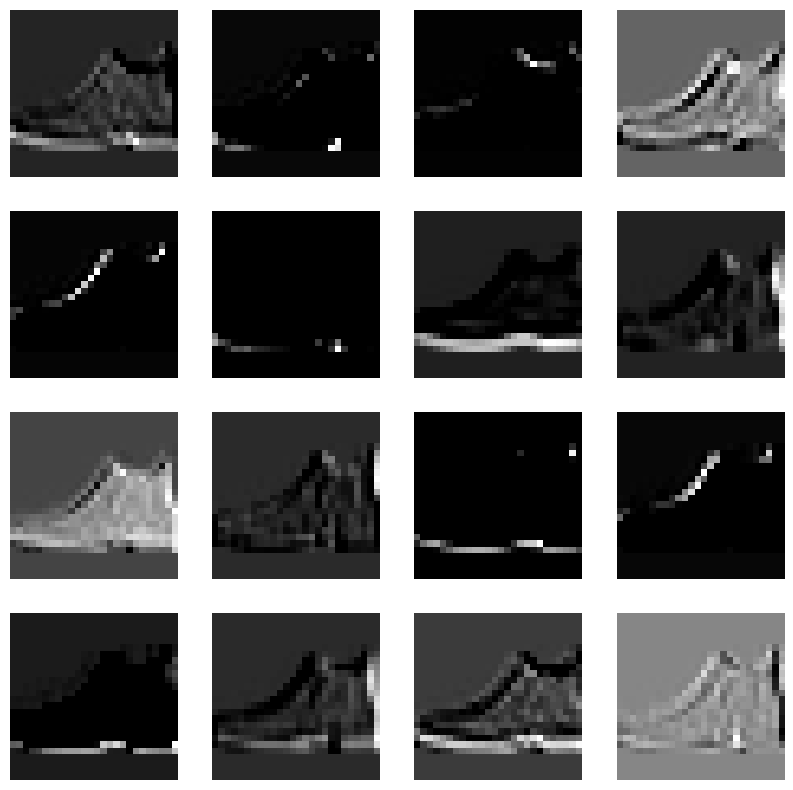

In [ ]:
import matplotlib.pyplot as plt

# Plot first conv layer feature maps
layer = feature_maps[0]

plt.figure(figsize=(10,10))

for i in range(16):  # show first 16 filters
    plt.subplot(4,4,i+1)
    plt.imshow(layer[0, :, :, i], cmap='gray')
    plt.axis('off')

plt.show()

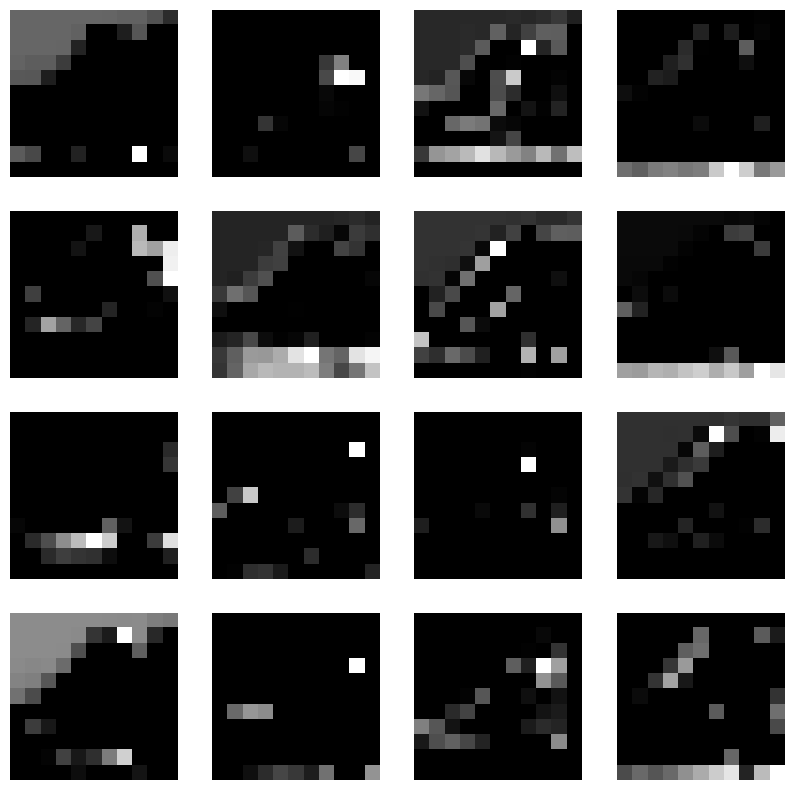

In [ ]:
layer = feature_maps[1]

plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(layer[0, :, :, i], cmap='gray')
    plt.axis('off')

plt.show()